# Block 4 — Longitudinal electromagnetic shower

This notebook validates the reusable mean-profile model implemented in `src/ams_ecal/longitudinal.py`. It deliberately does not implement shower physics a second time.

An electromagnetic cascade begins through bremsstrahlung and pair production. Particle multiplicity initially grows, secondary energies fall toward the effective critical energy $E_c$, and ionization/absorption eventually dominate. The gamma profile below is a **phenomenological parametrization** of that cascade, not an exact first-principles QED theorem.

## Mean gamma profile

With depth $t$ measured in radiation lengths $X_0$, the normalized mean energy-deposition density is

$$
f(t) = \frac{\beta (\beta t)^{\alpha-1} e^{-\beta t}}{\Gamma(\alpha)}.
$$

Its mode is

$$
T = t_{\max} = \frac{\alpha-1}{\beta}.
$$

For electron- and positron-induced showers, the PDG mean approximation is

$$
T(E) = \ln(E/E_c) - 0.5.
$$

AMS reports the detector-specific constant $\beta=0.65$. Therefore Block 4 uses $\alpha(E)=1+\beta T(E)$. The geometry supplies $E_c=7.6$ MeV, avoiding a duplicated material constant. Electron and positron mean profiles are identical at this level.

## Finite layer integration and leakage

For readout layer $l$ with finite bounds $[t_l^-, t_l^+]$,

$$
F_l = \int_{t_l^-}^{t_l^+} f(t)\,dt,
\qquad
E_l = E_{\mathrm{primary}} F_l.
$$

The 18 fractions are **not renormalized** to sum to one. The ECAL ends at $17X_0$, so $1-\sum_l F_l$ is the mean longitudinal leakage predicted by this idealized profile. SciPy's regularized incomplete gamma function evaluates the interval integrals reliably.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from ams_ecal import (
    AMSLongitudinalGammaModel,
    load_fastmc_config,
    load_geometry,
)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

geometry = load_geometry(PROJECT_ROOT / "configs" / "geometry.yaml")
fastmc_config = load_fastmc_config(PROJECT_ROOT / "configs" / "fastmc.yaml")
model = AMSLongitudinalGammaModel(
    config=fastmc_config.longitudinal_em,
    geometry=geometry,
)

In [2]:
print(f"Effective critical energy: {model.critical_energy_mev:.2f} MeV")
print(f"AMS gamma rate beta:     {model.config.gamma_rate:.2f}")
print(f"Finite ECAL depth:       {geometry.total_depth_x0:.1f} X0")
print(f"Readout intervals:       {geometry.number_of_layers}")

Effective critical energy: 7.60 MeV
AMS gamma rate beta:     0.65
Finite ECAL depth:       17.0 X0
Readout intervals:       18


## Energy dependence of the continuous profile

The profile maximum must move deeper by $\ln(10)$ radiation lengths for every decade in energy under this mean parametrization.

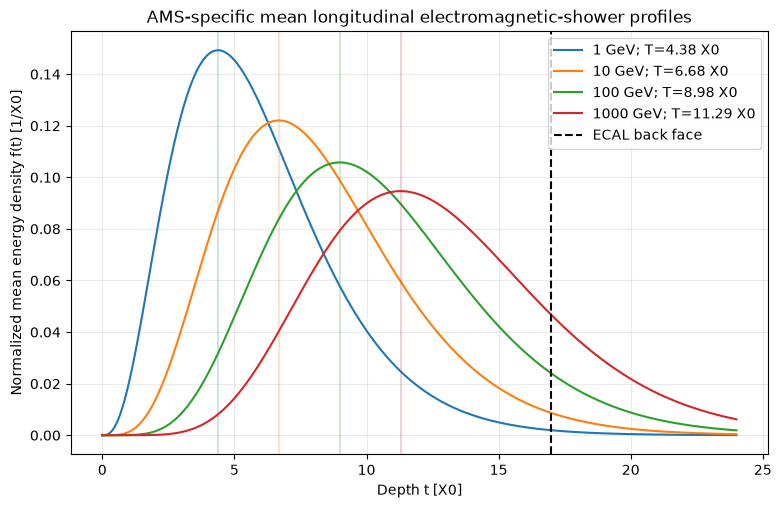

In [3]:
energies_gev = (1.0, 10.0, 100.0, 1000.0)
depths_x0 = np.linspace(0.0, 24.0, 1201)

fig, ax = plt.subplots(figsize=(9, 5.5))
for energy_gev in energies_gev:
    energy_mev = energy_gev * 1000.0
    density = np.array([
        model.energy_density(float(depth), energy_mev)
        for depth in depths_x0
    ])
    maximum_x0 = model.shower_max_depth_x0(energy_mev)
    ax.plot(depths_x0, density, label=f"{energy_gev:g} GeV; T={maximum_x0:.2f} X0")
    ax.axvline(maximum_x0, color=ax.lines[-1].get_color(), alpha=0.22)

ax.axvline(geometry.total_depth_x0, color="black", linestyle="--", label="ECAL back face")
ax.set(
    xlabel="Depth t [X0]",
    ylabel="Normalized mean energy density f(t) [1/X0]",
    title="AMS-specific mean longitudinal electromagnetic-shower profiles",
)
ax.grid(alpha=0.25)
ax.legend()
plt.show()

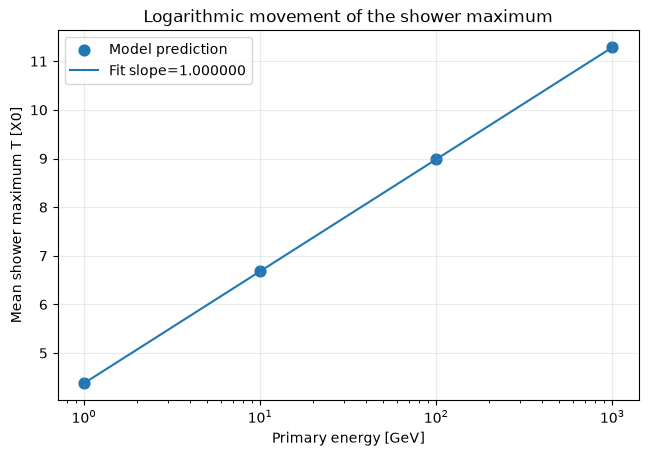

In [4]:
maxima_x0 = np.array([
    model.shower_max_depth_x0(energy_gev * 1000.0)
    for energy_gev in energies_gev
])
log_energy = np.log(np.array(energies_gev))
slope, intercept = np.polyfit(log_energy, maxima_x0, deg=1)

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.scatter(energies_gev, maxima_x0, s=60, label="Model prediction")
ax.plot(energies_gev, slope * log_energy + intercept, label=f"Fit slope={slope:.6f}")
ax.set_xscale("log")
ax.set(
    xlabel="Primary energy [GeV]",
    ylabel="Mean shower maximum T [X0]",
    title="Logarithmic movement of the shower maximum",
)
ax.grid(alpha=0.25)
ax.legend()
plt.show()

assert np.isclose(slope, 1.0, atol=1e-12)

## Discrete 18-layer fractions

The next plot uses interval-integrated layer fractions, not midpoint samples. Their sum remains below one whenever the continuous tail extends past the finite ECAL.

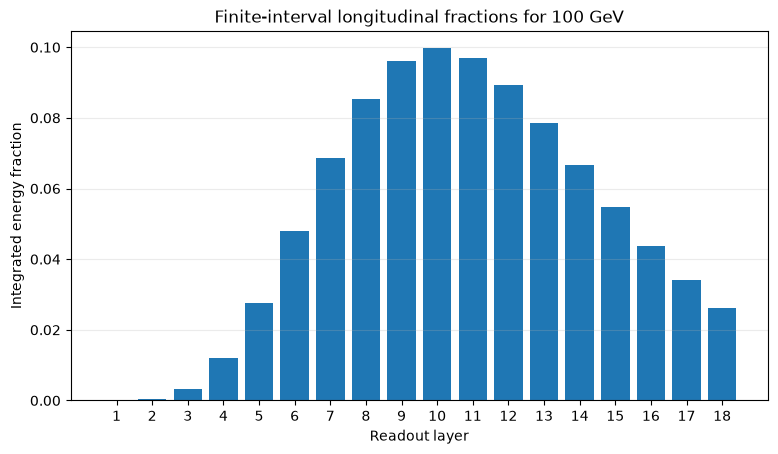

Contained fraction: 0.931310
Longitudinal leakage: 0.068690


In [5]:
energy_gev = 100.0
fractions = np.array(model.layer_energy_fractions(energy_gev * 1000.0))
layers = np.arange(1, geometry.number_of_layers + 1)

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.bar(layers, fractions, width=0.8)
ax.set(
    xlabel="Readout layer",
    ylabel="Integrated energy fraction",
    title=f"Finite-interval longitudinal fractions for {energy_gev:g} GeV",
)
ax.set_xticks(layers)
ax.grid(axis="y", alpha=0.25)
plt.show()

print(f"Contained fraction: {fractions.sum():.6f}")
print(f"Longitudinal leakage: {model.leakage_fraction(energy_gev * 1000.0):.6f}")

In [6]:
print("Energy [GeV] | T [X0] | contained | leakage")
for energy_gev in energies_gev:
    energy_mev = energy_gev * 1000.0
    contained = model.contained_fraction(energy_mev)
    print(
        f"{energy_gev:12g} | "
        f"{model.shower_max_depth_x0(energy_mev):6.3f} | "
        f"{contained:9.6f} | "
        f"{1.0 - contained:7.6f}"
    )

Energy [GeV] | T [X0] | contained | leakage
           1 |  4.380 |  0.996105 | 0.003895
          10 |  6.682 |  0.979580 | 0.020420
         100 |  8.985 |  0.931310 | 0.068690
        1000 | 11.287 |  0.833109 | 0.166891


## Validation summary

This block establishes the deterministic mean longitudinal backbone:

- the density rises, reaches the analytically predicted maximum, and falls;
- the maximum moves logarithmically deeper with energy;
- continuous profiles become 18 discrete values through finite-interval integration;
- electron and positron mean profiles agree;
- finite-depth leakage is preserved rather than normalized away.

It does **not** yet generate an event. Correlated shower fluctuations belong to Block 6, lateral spreading to Block 5, and detector response to Block 7.

In [7]:
for energy_gev in energies_gev:
    energy_mev = energy_gev * 1000.0
    electron = model.layer_energy_fractions(energy_mev, "electron")
    positron = model.layer_energy_fractions(energy_mev, "positron")
    assert electron == positron
    assert len(electron) == 18
    assert all(np.isfinite(electron))
    assert all(value >= 0.0 for value in electron)
    assert 0.0 < sum(electron) < 1.0

print("All Block-4 notebook validation checks passed.")

All Block-4 notebook validation checks passed.
